# Extended Data Figure 1 — K-Aggregation Curves

AUROC vs K at representative context lengths.  
**Source**: analysis.csv (all k values)  
**Tasks**: sex, sleep efficiency, apnea (selected per EXT_FIGURES_TASK_SELECTION.md — remaining tasks age/BMI/OSA stay in S-Fig 17)  
**Layout**: 1 row × 3 cols.  


In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="top", fontfamily="serif")

In [4]:
# Extended Data subset (see EXT_FIGURES_TASK_SELECTION.md)
TASKS    = ["sex_binary", "sleep_efficiency_binary", "apnea_binary"]
CONTEXTS = ["40m", "120m", "240m"]   # context lengths shown per panel
HEADS    = ["lstm", "transformer"]
N_COLS   = 3
N_ROWS   = 1   # 3 tasks → 1 × 3
ROW_H    = 2.6   # inches per row — increase for larger panels

import pandas as pd
_ana_path = WORKSPACE_ROOT / "final_results" / "phase0_v3" / "collected" / "analysis.csv"
df_all_k = pd.read_csv(_ana_path)
df_all_k["context_length_min"] = df_all_k["context_length"].map(
    lambda s: {"30s": 0.5, "10m": 10.0, "40m": 40.0,
               "80m": 80.0, "120m": 120.0, "240m": 240.0}.get(str(s).strip())
)
print("Tasks:", TASKS)
print("Loaded:", df_all_k.shape, "rows")

Tasks: ['sex_binary', 'sleep_efficiency_binary', 'apnea_binary']
Loaded: (1734, 26) rows


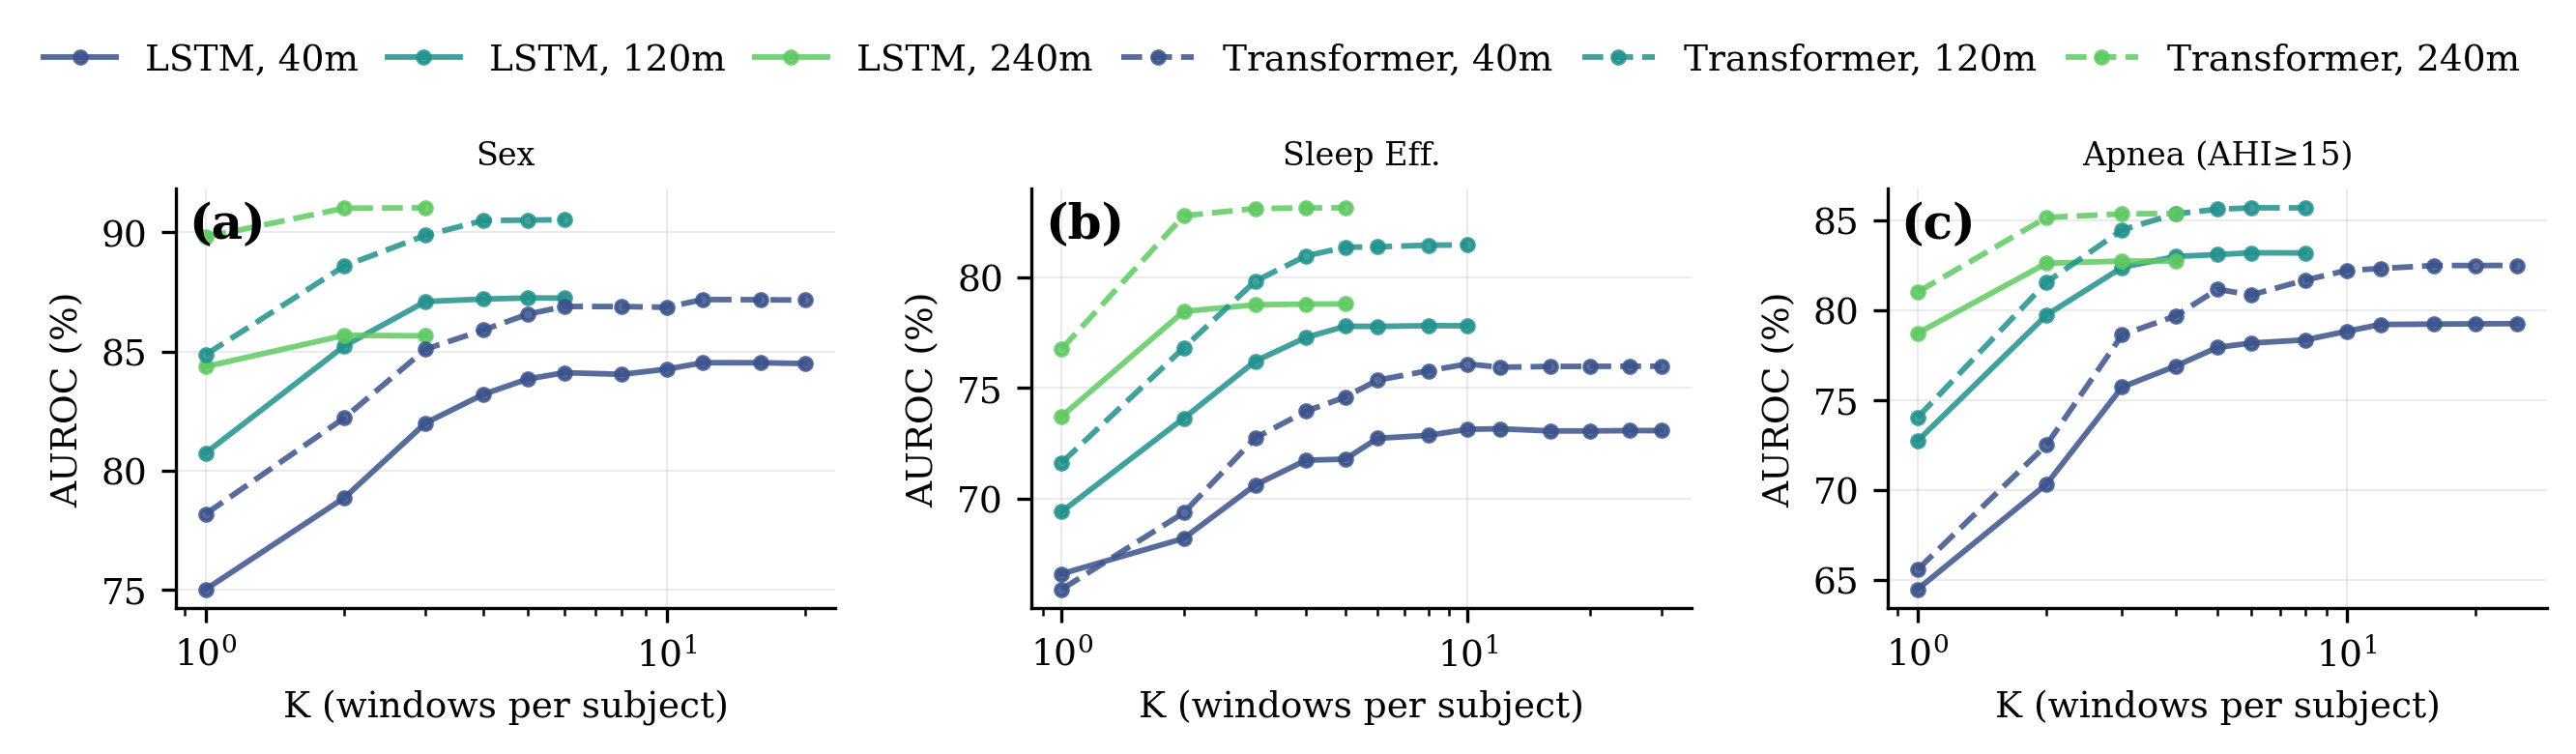

In [5]:
labels = [chr(97 + i) for i in range(len(TASKS))]

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(FULL_W+2, N_ROWS * ROW_H))
axes_flat = axes.flatten()

for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    panels.k_agg_panel(ax, df_all_k, task, heads=HEADS, contexts=CONTEXTS, show_legend=False)
    ax.set_title(TASK_LABEL.get(task, task), fontsize=8)
    add_panel_label(ax, f"({labels[i]})")

# Single shared horizontal legend at the top, grouped by head: "LSTM:" once,
# then its context lines, then "Transformer:" once, then its context lines.
from matplotlib.lines import Line2D

_handles, _leg_labels = axes_flat[0].get_legend_handles_labels()
_by_head = {}
for _h, _lbl in zip(_handles, _leg_labels):
    _head_name, _ctx_name = _lbl.split(", ")
    _by_head.setdefault(_head_name, []).append((_ctx_name, _h))

_legend_handles, _legend_labels = [], []
for _head_name in ["LSTM", "Transformer"]:
    _legend_handles.append(Line2D([], [], linestyle="None"))
    _legend_labels.append(f"{_head_name}:")
    for _ctx_name, _h in _by_head.get(_head_name, []):
        _legend_handles.append(_h)
        _legend_labels.append(_ctx_name)

fig.legend(_legend_handles, _legend_labels, loc="upper center",
           ncol=len(_legend_handles), fontsize=FONT_BASE, frameon=False,
           bbox_to_anchor=(0.5, 1.0), handlelength=2.0, columnspacing=0.8,
           handletextpad=0.4)

fig.tight_layout(h_pad=0.8, w_pad=1.0, rect=[0, 0, 1, 0.88])
plt.show()

In [ ]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "ext_fig1_k_aggregation")
import shutil
shutil.copy(FINAL_OUT / "ext_fig1_k_aggregation.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "ext_fig1_k_aggregation.pdf")
print("Saved + copied → npj_digital_medicine_submission/ext_fig1_k_aggregation.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/ext_fig1_k_aggregation.pdf
Saved + copied → npj_digital_medicine_submission/ext_fig1_k_aggregation.pdf
